In [1]:
!pip install tensorflow matplotlib

In [2]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense

In [3]:
#load MNIST dataset
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

print(X_train.shape)
print(X_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
(60000, 28, 28)
(10000, 28, 28)


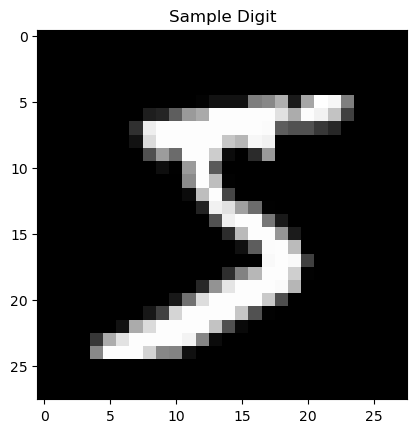

In [4]:
#display sample image 
plt.imshow(X_train[0], cmap='gray')
plt.title("Sample Digit")
plt.show()

In [5]:
#normalize image
X_train = X_train / 255.0
X_test = X_test / 255.0

In [6]:
#reshape dataset
X_train = X_train.reshape(60000, 28, 28, 1)
X_test = X_test.reshape(10000, 28, 28, 1)
print(X_train.shape)

(60000, 28, 28, 1)


In [11]:
#build CNN model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense

model = Sequential()

model.add(Input(shape=(28,28,1)))

model.add(
    Conv2D(
        32,
        (3,3),
        activation='relu'
    )
)

model.add(MaxPooling2D((2,2)))

model.add(Flatten())

model.add(Dense(128, activation='relu'))

model.add(Dense(10, activation='softmax'))

In [12]:
#complie mode
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [13]:
#train the model
history = model.fit(
    X_train,
    y_train,
    epochs=5,
    validation_data=(X_test, y_test)
)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 24s 11ms/step - accuracy: 0.9549 - loss: 0.1499 - val_accuracy: 0.9804 - val_loss: 0.0574
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - accuracy: 0.9847 - loss: 0.0511 - val_accuracy: 0.9844 - val_loss: 0.0486
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 21s 11ms/step - accuracy: 0.9898 - loss: 0.0323 - val_accuracy: 0.9845 - val_loss: 0.0427
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - accuracy: 0.9936 - loss: 0.0212 - val_accuracy: 0.9865 - val_loss: 0.0443
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - accuracy: 0.9949 - loss: 0.0151 - val_accuracy: 0.9870 - val_loss: 0.0417


In [14]:
#check accuracy 
loss, accuracy = model.evaluate(X_test, y_test)

print("Accuracy:", accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9870 - loss: 0.0417
Accuracy: 0.9869999885559082


In [15]:
#predict digit
prediction = model.predict(X_test)

predicted_digit = np.argmax(prediction[0])

print("Predicted Digit:", predicted_digit)

print("Actual Digit:", y_test[0])

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
Predicted Digit: 7
Actual Digit: 7


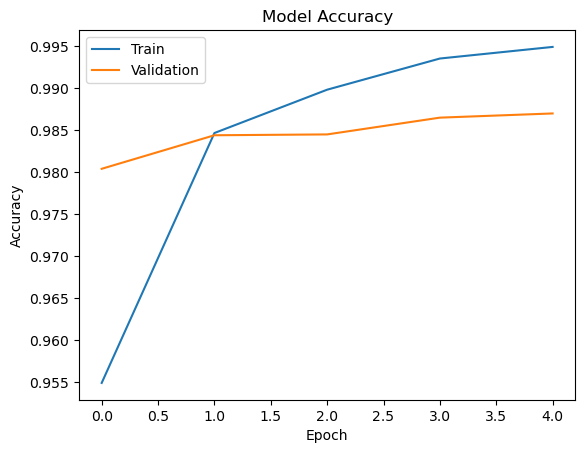

In [16]:
#accuracy graph
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')

plt.ylabel('Accuracy')
plt.xlabel('Epoch')

plt.legend(['Train', 'Validation'])

plt.show()

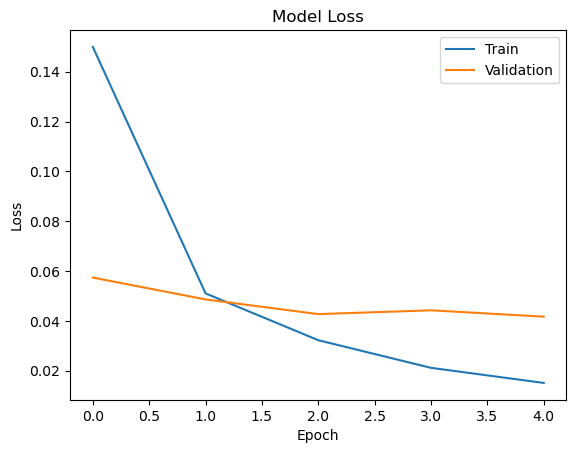

In [18]:
#loss graph
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('Model Loss')

plt.ylabel('Loss')
plt.xlabel('Epoch')

plt.legend(['Train', 'Validation'])

plt.show()

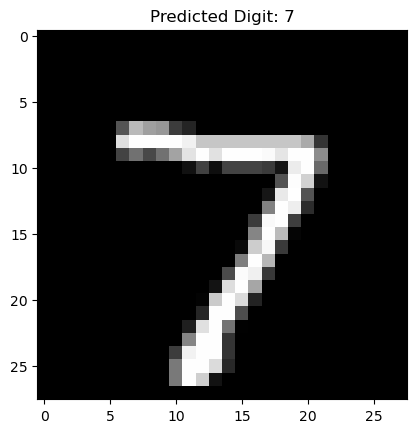

In [20]:
#show predict image 
plt.imshow(X_test[0].reshape(28,28), cmap='gray')

plt.title(f"Predicted Digit: {predicted_digit}")

plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


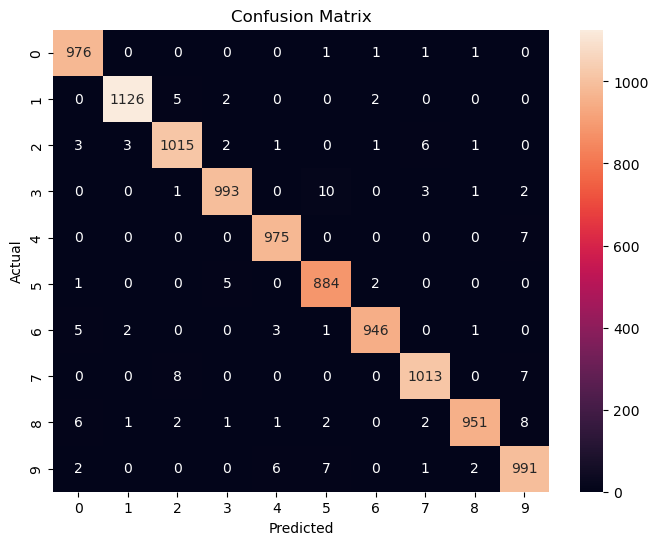

In [21]:
#confusion matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns

y_pred = model.predict(X_test)

y_pred_classes = np.argmax(y_pred, axis=1)

cm = confusion_matrix(y_test, y_pred_classes)

plt.figure(figsize=(8,6))

sns.heatmap(cm, annot=True, fmt='d')

plt.title("Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [22]:
#classisfication report
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_classes))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.98      0.98      0.98      1032
           3       0.99      0.98      0.99      1010
           4       0.99      0.99      0.99       982
           5       0.98      0.99      0.98       892
           6       0.99      0.99      0.99       958
           7       0.99      0.99      0.99      1028
           8       0.99      0.98      0.98       974
           9       0.98      0.98      0.98      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



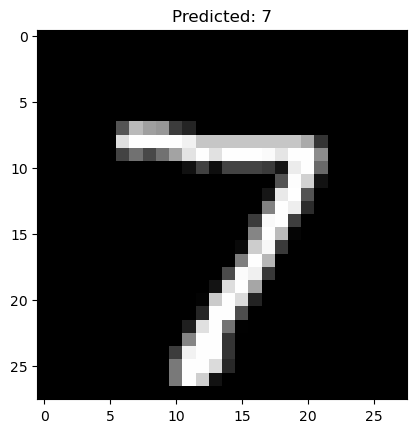

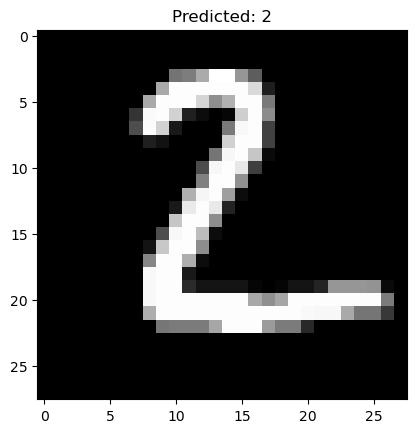

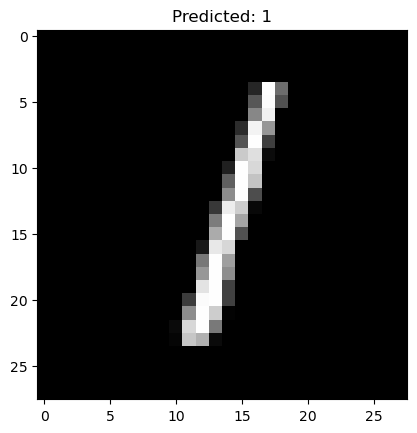

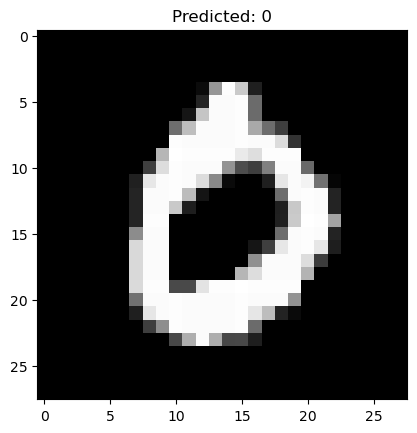

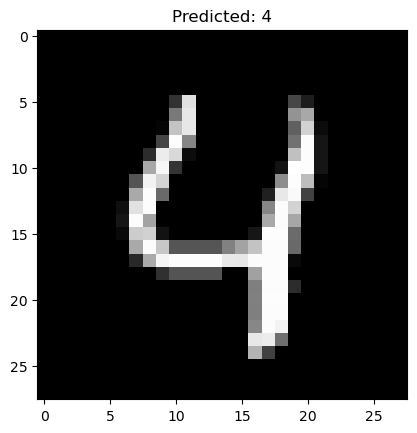

In [23]:
#multiple prediction
for i in range(5):

    plt.imshow(X_test[i].reshape(28,28), cmap='gray')

    plt.title(f"Predicted: {y_pred_classes[i]}")

    plt.show()

In [24]:
#save model
model.save("handwritten_character_model.keras")

print("Model Saved Successfully")

Model Saved Successfully
